# A rendre pour le 12 Octobre 2025 , 00h00

# Exercice 1

Le but de cet exercice est d'utiliser de manière avancée la classe nn.Module de Pytorch.
Pour ce faire, il faut créer un Module Pytorch dont les paramètres seront la combinaison linéaire de autres modules semblables.

In [1]:
import torch
import torch.nn as nn

In [2]:
# Fully connected neural network with one hidden layer
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, out_dim):
        """
        Args
        input_size : Taille d'entrée
        hidden_size : dimension couches cachées
        out_dim : dimension de sortie

        """
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size) 
        self.activation = nn.Sigmoid()
        self.fc2 = nn.Linear(hidden_size, hidden_size)  
        self.fc3 = nn.Linear(hidden_size, out_dim) 

    
    def forward(self, x):
        
        out = self.fc1(x)
        out = self.activation(out)
        out = self.fc2(out)
        out = self.activation(out)
        out = self.fc3(out)
        return out

In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [4]:
input_size = 1
hidden_size = 32
num_classes = 1
modelA = NeuralNet(input_size, hidden_size, num_classes).to(device)
modelB = NeuralNet(input_size, hidden_size, num_classes).to(device)

c:\Users\natha\Documents\Git\5th-year-polytech\transformers\env\Lib\site-packages\torch\nn\modules\module.py:1355: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:35.)
  return t.to(


Modifier la classe ci-dessous pour que chaque paramètre du modèle soit une combinaison lineaire des modèles

# Create the model

In [5]:
class LinearNeuralNet(nn.Module):
    def __init__(self, model1: NeuralNet, model2: NeuralNet, coeffs: nn.Parameter):
        """
        Args:
            model1 : Modèle d'entrée 1
            model2 : Modèle d'entrée 2
            coeffs : coefficients des modèles (ex: [α, β])
        """
        super(LinearNeuralNet, self).__init__()

        # Enregistrer les modèles et les coefficients
        self.model1 = model1
        self.model2 = model2
        self.coeffs = coeffs  # nn.Parameter, par ex. torch.nn.Parameter(torch.tensor([0.5, 0.5]))

        # Créer une copie du même architecture pour héberger la combinaison linéaire
        self.model = NeuralNet(
            input_size=model1.fc1.in_features,
            hidden_size=model1.fc1.out_features,
            out_dim=model1.fc3.out_features
        )

        # Mettre à jour les poids selon la combinaison linéaire
        self.update_linear_combination()

    def update_linear_combination(self):
        """Met à jour les poids du modèle combiné selon les coefficients."""
        alpha, beta = self.coeffs

        # On suppose que model1 et model2 ont la même architecture
        with torch.no_grad():
            for (name, param), (_, p1), (_, p2) in zip(
                self.model.named_parameters(),
                self.model1.named_parameters(),
                self.model2.named_parameters()
            ):
                param.copy_(alpha * p1 + beta * p2)

    def forward(self, x):
        # Met à jour la combinaison avant chaque passage avant
        self.update_linear_combination()
        return self.model(x)

In [6]:
coeffs =nn.Parameter(torch.randn(2))
combined_model = LinearNeuralNet(modelA,modelB,coeffs)

# Exercice 2  :  Charger le dataset suivant dans pytorch et afficher des images de chaque classe: 
https://drive.google.com/file/d/1V_zyw7kZ1YnPYM4VzCtP9agY7PiFuH-P/view?usp=sharing

Ecrire une classe Dataset permettant de charger de manière efficace le dataset enregistré à l'addresse ci-dessus

Chaque dossier d'entrée constitue un label du dataset

Votre classe doit retourner deux valeurs : L'image x et le label y  ( Entier) .

Il n'est pas autorisé d'utiliser des fonctions custom Pytorch en lien avec torch.utils.data.Dataset.

Le squelette de code suivant est un point de départ pour vous.

## Le code sera testé pour: 
* sa capacité à afficher n'importe quelle image et son label
* sa rapidité d'execution pour charger toutes les images

Le code de vérification et de mesure du temps d'execution sera fourni.

### Une bonification sera appliquée pour tout code qui pourra aussi charger automatiquement un autre dataset semblable qui sera revelé après le depot des devoirs.

In [44]:
import os
from concurrent.futures import ThreadPoolExecutor
from PIL import Image
from tqdm import tqdm
import pandas as pd
import torch
import matplotlib.pyplot as plt

class mondataset(torch.utils.data.Dataset):
    def __init__(self, path):
        self.__data_path = path
        self.__load_labels()
        self.__load_images()

    def __load_labels(self):
        """Load all image labels stored in the given data path"""
        labels = sorted(os.listdir(self.__data_path))
        self.__ids_to_labels = {idx: label for idx, label in enumerate(labels)}
        self.__labels_to_ids = {label: idx for idx, label in enumerate(labels)}

    def get_ids_to_labels(self):
        """Returns a dictionary mapping all label ids to their corresponding labels"""
        return self.__ids_to_labels

    def get_labels_to_ids(self):
        """Returns a dictionary mapping all image labels to their corresponding ids"""
        return self.__labels_to_ids

    def __read_image(self, path):
        """Reads a .png image using PIL.Image based on a specified path"""
        with Image.open(path) as img:
            return img.convert("RGB").copy()

    def __find_all_images(self):
        """Finds all image paths from the specified data path"""
        import time
        start = time.time()
        image_paths = []
        for idx, label in self.__ids_to_labels.items():
            current_path = os.path.join(self.__data_path, label)
            for dirpath, dirnames, filenames in os.walk(current_path):
                for fname in filenames:
                    if fname.lower().endswith(".png"):
                        image_paths.append([idx, os.path.join(dirpath, fname)])
        self.__df_images = pd.DataFrame(image_paths, columns=["label_id", "image_path"])
        end = time.time()
        print(f"find_all_images duration: {end - start:.2f} seconds")

    def __load_images(self):
        """Loads all images stored in the data"""
        self.__find_all_images()
        with ThreadPoolExecutor(max_workers=4) as executor:
            tqdm_func = tqdm(executor.map(self.__read_image, self.__df_images["image_path"]),
                             total=len(self.__df_images), desc="Load images...")
            self.__df_images["image"] = list(tqdm_func)
            self.__df_images.drop("image_path", axis=1, inplace=True)
            self.__df_images["label_name"] = self.__df_images["label_id"].map(self.__ids_to_labels)

    def __len__(self):
        return len(self.__df_images)

    def __getitem__(self, idx):
        row = self.__df_images.iloc[idx]
        x = row["image"]
        y = row["label_id"]
        return x, y

    def show_image(self, idx):
        """Shows (using MatPlotLib) the idx-th image of the dataset"""
        plt.imshow(self.__df_images.iloc[idx]["image"])
        plt.show()

find_all_images duration: 0.08 seconds


Load images...: 100%|██████████| 4752/4752 [00:03<00:00, 1351.46it/s]


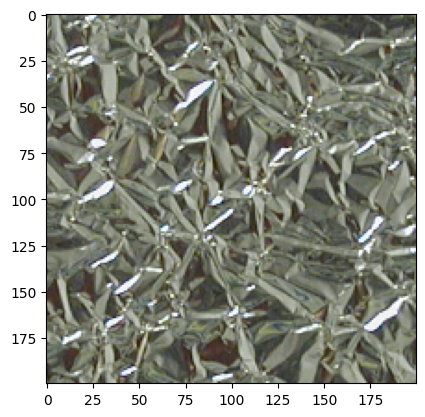

In [45]:
dataset = mondataset("data")
dataset.show_image(0)